# Classic Train/Test Split Benchmark
Benchmarks 10 ML models (3 classical + 7 deep learning) on MultiPhysio-HRC fusion dataset using classic 80/20 train-test split.

In [5]:
# SECTION 0: Colab Setup (if running on Colab)
import sys
from pathlib import Path

try:
    from google.colab import drive
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    try:
        drive.mount('/content/drive', force_remount=False)
    except Exception:
        pass
    ROOT = Path('/content/drive/MyDrive')
else:
    ROOT = Path('/home/g0amer/Desktop/thesis')

# Output directory for this notebook
BASE_DIR = ROOT / 'research_outputs' / 'fusion_training' / 'v2_classic_split_benchmark'
BASE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Running on Colab: {IS_COLAB}")
print(f"Root directory: {ROOT}")
print(f"Base output dir: {BASE_DIR}")

# SECTION 1: Import Required Libraries
import numpy as np
import pandas as pd
import warnings
import copy
import pickle
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional
import time
import json

# Data & ML
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# XGBoost (optional)
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost not installed; will skip XGBoost model.")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print("Libraries imported successfully!")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Torch device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

Running on Colab: False
Root directory: /home/g0amer/Desktop/thesis
Base output dir: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_classic_split_benchmark
Libraries imported successfully!
CUDA available: True
Torch device: cuda


In [6]:
# SECTION 2: Load and Prepare Data
FUSION_PATH = ROOT / 'research_outputs' / 'fusion' / 'v1_fusion' / 'fusion_dataset.csv'
if not FUSION_PATH.exists():
    raise FileNotFoundError(FUSION_PATH)

df = pd.read_csv(FUSION_PATH)
print(f"Dataset loaded: {df.shape}")
print(f"Columns: {df.shape[1]}")
print(f"\nFirst rows:")
print(df.head())
print(f"\nData types:\n{df.dtypes}")

# Check label column
label_col = 'label' if 'label' in df.columns else 'pseudo_label'
if label_col not in df.columns:
    raise ValueError('No label or pseudo_label column found.')
print(f"\nLabel column: {label_col}")
print(f"Unique labels: {df[label_col].nunique()}")
print(f"Label distribution:\n{df[label_col].value_counts()}")

Dataset loaded: (5640, 257)
Columns: 257

First rows:
   subject_id     task_name         task_file     split  ID__mean  ID__std  \
0       10000  cobot-task-1  cobot-task-1.csv  filtered       0.0      0.0   
1       10000  cobot-task-1  cobot-task-1.csv  filtered       0.0      0.0   
2       10000  cobot-task-1  cobot-task-1.csv  filtered       0.0      0.0   
3       10000  cobot-task-1  cobot-task-1.csv  filtered       0.0      0.0   
4       10000  cobot-task-1  cobot-task-1.csv  filtered       0.0      0.0   

   ID__min  ID__max  ID__median  ID__p25  ...  \
0      0.0      0.0         0.0      0.0  ...   
1      0.0      0.0         0.0      0.0  ...   
2      0.0      0.0         0.0      0.0  ...   
3      0.0      0.0         0.0      0.0  ...   
4      0.0      0.0         0.0      0.0  ...   

   eeg_features_5s__EEG_channel_11__median  \
0                                 0.713396   
1                                 0.711946   
2                                 0.710220  

In [7]:
# Prepare features and labels
meta_cols = {'subject_id', 'task_name', 'task_file', 'split', 'window_idx', 'start_idx', 'end_idx', 'n_samples', 'label', 'pseudo_label'}
feature_cols = [c for c in df.columns if c not in meta_cols]

# Keep numeric features only; coerce strings like "filtered" to NaN
numeric_df = df[feature_cols].apply(pd.to_numeric, errors='coerce')
usable_feature_cols = [c for c in numeric_df.columns if numeric_df[c].notna().any()]
X_raw = numeric_df[usable_feature_cols].copy()
y_raw = df[label_col].astype(str).fillna('NA')

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)

print(f"Classes: {list(le.classes_)}")
print(f"Feature matrix shape before imputation: {X_raw.shape}")
print(f"Label vector shape: {y.shape}")
print(f"Usable features: {len(usable_feature_cols)}")
print(f"Missing values in features: {int(X_raw.isna().sum().sum())}")
print(f"Class distribution (encoded):")
for i, cls in enumerate(le.classes_):
    count = np.sum(y == i)
    print(f"  {i}: {cls} ({count} samples, {100*count/len(y):.1f}%)")

Classes: ['cognitive_load', 'high_stress', 'industrial_task', 'low_load', 'other']
Feature matrix shape before imputation: (5640, 247)
Label vector shape: (5640,)
Usable features: 247
Missing values in features: 328
Class distribution (encoded):
  0: cognitive_load (975 samples, 17.3%)
  1: high_stress (224 samples, 4.0%)
  2: industrial_task (3571 samples, 63.3%)
  3: low_load (799 samples, 14.2%)
  4: other (71 samples, 1.3%)


In [8]:
# SECTION 3: Split Data into Train and Test Sets
test_size = 0.2
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=test_size, random_state=random_state, stratify=y
)

# Impute missing values, then standardize features
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print(f"Train set: {X_train_scaled.shape}, {np.bincount(y_train)}")
print(f"Test set: {X_test_scaled.shape}, {np.bincount(y_test)}")
print(f"\nTrain/Test split: {100*(1-test_size):.0f}% / {100*test_size:.0f}%")
print(f"Random seed: {random_state}")

Train set: (4512, 247), [ 780  179 2857  639   57]
Test set: (1128, 247), [195  45 714 160  14]

Train/Test split: 80% / 20%
Random seed: 42


In [9]:
# Verify data path exists
print(f"\n{'='*60}")
print("DATA PATH VERIFICATION")
print(f"{'='*60}")
print(f"Looking for data at: {FUSION_PATH}")
print(f"Path exists: {FUSION_PATH.exists()}")

if not FUSION_PATH.exists():
    print("\nTroubleshooting:")
    print(f"  - Check if ROOT is correct: {ROOT}")
    print(f"  - Check if running on Colab: {IS_COLAB}")
    if IS_COLAB:
        print("  - Ensure Google Drive is mounted at /content/drive")
        print("  - Verify path in Drive: MyDrive/research_outputs/fusion/v1_fusion/fusion_dataset.csv")
    raise FileNotFoundError(f"Dataset not found at {FUSION_PATH}")

print("Data file is available; proceed with feature preparation and splitting.")


DATA PATH VERIFICATION
Looking for data at: /home/g0amer/Desktop/thesis/research_outputs/fusion/v1_fusion/fusion_dataset.csv
Path exists: True
Data file is available; proceed with feature preparation and splitting.


In [10]:
# Configuration for deep learning models
@dataclass
class BenchConfig:
    max_epochs: int = 100
    batch_size: int = 256
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    hidden_dim: int = 128
    dropout: float = 0.2
    patience: int = 5
    verbose: bool = True

CFG = BenchConfig()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Config: max_epochs={CFG.max_epochs}, batch_size={CFG.batch_size}, lr={CFG.learning_rate}")

Device: cuda
Config: max_epochs=100, batch_size=256, lr=0.001


In [11]:
# SECTION 4: PyTorch Dataset and Model Utilities

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class SequenceDataset(Dataset):
    def __init__(self, X_seq, y):
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def compute_class_weights(y_arr):
    classes = np.unique(y_arr)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_arr)
    print(f"Class weights: {dict(zip(classes, weights))}")
    return torch.tensor(weights, dtype=torch.float32)

# Neural Network Models
class MLPNet(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_classes),
        )
    
    def forward(self, x):
        return self.net(x)

class LSTMNet(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dim=128, dropout=0.2, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=bidirectional, dropout=dropout)
        out_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(out_dim, n_classes))
    
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        if self.bidirectional:
            h_last = torch.cat((h[-2], h[-1]), dim=1)
        else:
            h_last = h[-1]
        return self.head(h_last)

class GRUNet(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dim=128, dropout=0.2, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True, bidirectional=bidirectional, dropout=dropout)
        out_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(out_dim, n_classes))
    
    def forward(self, x):
        _, h = self.gru(x)
        if self.bidirectional:
            h_last = torch.cat((h[-2], h[-1]), dim=1)
        else:
            h_last = h[-1]
        return self.head(h_last)

class TCNNet(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1), nn.ReLU(), nn.Dropout(dropout),
        )
        self.head = nn.Linear(hidden_dim, n_classes)
    
    def forward(self, x):
        # x: (batch, seq_len, features) -> (batch, features, seq_len)
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.mean(dim=2)  # Global average pooling
        return self.head(x)

class TransformerNet(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dim=128, dropout=0.2, n_heads=4, n_layers=2):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads, dim_feedforward=hidden_dim*4, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.embed = nn.Linear(input_dim, hidden_dim)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_dim, n_classes))
    
    def forward(self, x):
        x = self.embed(x)
        x = self.transformer(x)
        x = x.mean(dim=1)  # Global average pooling
        return self.head(x)

print("PyTorch utilities and models defined.")

PyTorch utilities and models defined.


In [12]:
# Training/Evaluation Utilities

def train_torch_model(model, train_loader, val_loader, n_classes, device, model_name="Model"):
    criterion = nn.CrossEntropyLoss(weight=compute_class_weights(y_train).to(device))
    optimizer = optim.Adam(model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay)
    best_val_f1, best_model, patience_count = 0.0, None, 0
    
    for epoch in range(CFG.max_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        with torch.no_grad():
            val_preds, val_targets = [], []
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                val_preds.append(logits.argmax(dim=1).cpu().numpy())
                val_targets.append(y_batch.cpu().numpy())
            val_preds = np.concatenate(val_preds)
            val_targets = np.concatenate(val_targets)
            val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)
        
        if val_f1 > best_val_f1:
            best_val_f1, best_model, patience_count = val_f1, copy.deepcopy(model.state_dict()), 0
        else:
            patience_count += 1
        
        if CFG.verbose and (epoch + 1) % max(1, CFG.max_epochs // 5) == 0:
            print(f"[{model_name}] Epoch {epoch+1}/{CFG.max_epochs} | train_loss={train_loss/len(train_loader):.4f} | val_f1={val_f1:.4f} | best={best_val_f1:.4f}")
        
        if patience_count >= CFG.patience:
            print(f"[{model_name}] Early stopping at epoch {epoch+1}")
            break
    
    if best_model is not None:
        model.load_state_dict(best_model)
    
    return model

def evaluate_model(model, test_loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            preds.append(logits.argmax(dim=1).cpu().numpy())
            targets.append(y_batch.cpu().numpy())
    
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    
    acc = accuracy_score(targets, preds)
    balanced_acc = balanced_accuracy_score(targets, preds)
    macro_f1 = f1_score(targets, preds, average='macro', zero_division=0)
    
    return {'accuracy': acc, 'balanced_accuracy': balanced_acc, 'macro_f1': macro_f1, 'y_true': targets, 'y_pred': preds}

print("Training and evaluation utilities defined.")

Training and evaluation utilities defined.


In [13]:
# SECTION 5.1: Train Classical Models - Logistic Regression
print("="*60)
print("Training: Logistic Regression")
print("="*60)

start = time.time()
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
logreg.fit(X_train_scaled, y_train)
fit_time_logreg = time.time() - start

start = time.time()
y_pred_logreg = logreg.predict(X_test_scaled)
pred_time_logreg = time.time() - start

acc_logreg = accuracy_score(y_test, y_pred_logreg)
balanced_acc_logreg = balanced_accuracy_score(y_test, y_pred_logreg)
macro_f1_logreg = f1_score(y_test, y_pred_logreg, average='macro', zero_division=0)

print(f"Fit time: {fit_time_logreg:.2f}s")
print(f"Accuracy: {acc_logreg:.4f}")
print(f"Balanced Accuracy: {balanced_acc_logreg:.4f}")
print(f"Macro-F1: {macro_f1_logreg:.4f}")

Training: Logistic Regression


Fit time: 25.80s
Accuracy: 0.7739
Balanced Accuracy: 0.7164
Macro-F1: 0.6730


In [14]:
# SECTION 5.2: Train Classical Models - Random Forest
print("="*60)
print("Training: Random Forest")
print("="*60)

start = time.time()
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
fit_time_rf = time.time() - start

start = time.time()
y_pred_rf = rf.predict(X_test_scaled)
pred_time_rf = time.time() - start

acc_rf = accuracy_score(y_test, y_pred_rf)
balanced_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)
macro_f1_rf = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

print(f"Fit time: {fit_time_rf:.2f}s")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Balanced Accuracy: {balanced_acc_rf:.4f}")
print(f"Macro-F1: {macro_f1_rf:.4f}")

Training: Random Forest
Fit time: 0.62s
Accuracy: 0.9149
Balanced Accuracy: 0.8249
Macro-F1: 0.8660


In [15]:
# SECTION 5.3: Train Classical Models - XGBoost
if HAS_XGBOOST:
    print("="*60)
    print("Training: XGBoost")
    print("="*60)
    
    # Compute class weights for XGBoost
    classes = np.unique(y_train)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
    sample_weights = class_weights[y_train]
    
    start = time.time()
    xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1, verbosity=0)
    xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights, verbose=False)
    fit_time_xgb = time.time() - start
    
    start = time.time()
    y_pred_xgb = xgb.predict(X_test_scaled)
    pred_time_xgb = time.time() - start
    
    acc_xgb = accuracy_score(y_test, y_pred_xgb)
    balanced_acc_xgb = balanced_accuracy_score(y_test, y_pred_xgb)
    macro_f1_xgb = f1_score(y_test, y_pred_xgb, average='macro', zero_division=0)
    
    print(f"Fit time: {fit_time_xgb:.2f}s")
    print(f"Accuracy: {acc_xgb:.4f}")
    print(f"Balanced Accuracy: {balanced_acc_xgb:.4f}")
    print(f"Macro-F1: {macro_f1_xgb:.4f}")
else:
    print("XGBoost not available; skipping.")

Training: XGBoost
Fit time: 5.55s
Accuracy: 0.9335
Balanced Accuracy: 0.8812
Macro-F1: 0.8964


In [16]:
# SECTION 5.4: Prepare sequence data for RNN models
# For sequence models, we'll reshape tabular features into 1D sequences
# This is a simplified approach; for real sequences, you'd use temporal windows

n_features = X_train_scaled.shape[1]
seq_len = max(1, n_features // 4)  # Create artificial sequence length

def reshape_to_sequences(X, seq_len):
    """Reshape (N, F) to (N, seq_len, F/seq_len) for sequence models."""
    n_samples, n_features = X.shape
    feat_per_step = max(1, n_features // seq_len)
    X_seq = X[:, :seq_len*feat_per_step].reshape(n_samples, seq_len, feat_per_step)
    return X_seq

X_train_seq = reshape_to_sequences(X_train_scaled, seq_len)
X_test_seq = reshape_to_sequences(X_test_scaled, seq_len)

print(f"Original feature shape: {X_train_scaled.shape}")
print(f"Sequence shape (train): {X_train_seq.shape}")
print(f"Sequence shape (test): {X_test_seq.shape}")

# Create DataLoaders
train_dataset_tab = TabularDataset(X_train_scaled, y_train)
test_dataset_tab = TabularDataset(X_test_scaled, y_test)
train_loader_tab = DataLoader(train_dataset_tab, batch_size=CFG.batch_size, shuffle=True)
test_loader_tab = DataLoader(test_dataset_tab, batch_size=CFG.batch_size, shuffle=False)

train_dataset_seq = SequenceDataset(X_train_seq, y_train)
test_dataset_seq = SequenceDataset(X_test_seq, y_test)
train_loader_seq = DataLoader(train_dataset_seq, batch_size=CFG.batch_size, shuffle=True)
test_loader_seq = DataLoader(test_dataset_seq, batch_size=CFG.batch_size, shuffle=False)

print("DataLoaders created.")

Original feature shape: (4512, 247)
Sequence shape (train): (4512, 61, 4)
Sequence shape (test): (1128, 61, 4)
DataLoaders created.


In [17]:
# SECTION 5.5: Train Deep Learning Model - MLP
print("="*60)
print("Training: MLP")
print("="*60)

mlp = MLPNet(X_train_scaled.shape[1], len(le.classes_), hidden_dim=CFG.hidden_dim).to(device)
start = time.time()
mlp = train_torch_model(mlp, train_loader_tab, test_loader_tab, len(le.classes_), device, "MLP")
fit_time_mlp = time.time() - start

start = time.time()
mlp_results = evaluate_model(mlp, test_loader_tab, device)
pred_time_mlp = time.time() - start

print(f"Fit time: {fit_time_mlp:.2f}s")
print(f"Accuracy: {mlp_results['accuracy']:.4f}")
print(f"Balanced Accuracy: {mlp_results['balanced_accuracy']:.4f}")
print(f"Macro-F1: {mlp_results['macro_f1']:.4f}")

Training: MLP
Class weights: {np.int64(0): np.float64(1.156923076923077), np.int64(1): np.float64(5.041340782122905), np.int64(2): np.float64(0.3158557927896395), np.int64(3): np.float64(1.412206572769953), np.int64(4): np.float64(15.83157894736842)}
[MLP] Epoch 20/100 | train_loss=0.2445 | val_f1=0.8216 | best=0.8259
[MLP] Early stopping at epoch 27
Fit time: 2.75s
Accuracy: 0.9025
Balanced Accuracy: 0.8890
Macro-F1: 0.8673


In [18]:
# SECTION 5.6: Train Deep Learning Model - LSTM
print("="*60)
print("Training: LSTM")
print("="*60)

lstm = LSTMNet(X_train_seq.shape[-1], len(le.classes_), hidden_dim=CFG.hidden_dim, bidirectional=False).to(device)
start = time.time()
lstm = train_torch_model(lstm, train_loader_seq, test_loader_seq, len(le.classes_), device, "LSTM")
fit_time_lstm = time.time() - start

start = time.time()
lstm_results = evaluate_model(lstm, test_loader_seq, device)
pred_time_lstm = time.time() - start

print(f"Fit time: {fit_time_lstm:.2f}s")
print(f"Accuracy: {lstm_results['accuracy']:.4f}")
print(f"Balanced Accuracy: {lstm_results['balanced_accuracy']:.4f}")
print(f"Macro-F1: {lstm_results['macro_f1']:.4f}")

Training: LSTM
Class weights: {np.int64(0): np.float64(1.156923076923077), np.int64(1): np.float64(5.041340782122905), np.int64(2): np.float64(0.3158557927896395), np.int64(3): np.float64(1.412206572769953), np.int64(4): np.float64(15.83157894736842)}
[LSTM] Early stopping at epoch 14
Fit time: 2.35s
Accuracy: 0.5337
Balanced Accuracy: 0.4050
Macro-F1: 0.3458


In [19]:
# SECTION 5.7: Train Deep Learning Model - GRU
print("="*60)
print("Training: GRU")
print("="*60)

gru = GRUNet(X_train_seq.shape[-1], len(le.classes_), hidden_dim=CFG.hidden_dim, bidirectional=False).to(device)
start = time.time()
gru = train_torch_model(gru, train_loader_seq, test_loader_seq, len(le.classes_), device, "GRU")
fit_time_gru = time.time() - start

start = time.time()
gru_results = evaluate_model(gru, test_loader_seq, device)
pred_time_gru = time.time() - start

print(f"Fit time: {fit_time_gru:.2f}s")
print(f"Accuracy: {gru_results['accuracy']:.4f}")
print(f"Balanced Accuracy: {gru_results['balanced_accuracy']:.4f}")
print(f"Macro-F1: {gru_results['macro_f1']:.4f}")

Training: GRU
Class weights: {np.int64(0): np.float64(1.156923076923077), np.int64(1): np.float64(5.041340782122905), np.int64(2): np.float64(0.3158557927896395), np.int64(3): np.float64(1.412206572769953), np.int64(4): np.float64(15.83157894736842)}
[GRU] Early stopping at epoch 12
Fit time: 1.38s
Accuracy: 0.4096
Balanced Accuracy: 0.4156
Macro-F1: 0.3478


In [20]:
# SECTION 5.8: Train Deep Learning Model - BiLSTM
print("="*60)
print("Training: BiLSTM")
print("="*60)

bilstm = LSTMNet(X_train_seq.shape[-1], len(le.classes_), hidden_dim=CFG.hidden_dim, bidirectional=True).to(device)
start = time.time()
bilstm = train_torch_model(bilstm, train_loader_seq, test_loader_seq, len(le.classes_), device, "BiLSTM")
fit_time_bilstm = time.time() - start

start = time.time()
bilstm_results = evaluate_model(bilstm, test_loader_seq, device)
pred_time_bilstm = time.time() - start

print(f"Fit time: {fit_time_bilstm:.2f}s")
print(f"Accuracy: {bilstm_results['accuracy']:.4f}")
print(f"Balanced Accuracy: {bilstm_results['balanced_accuracy']:.4f}")
print(f"Macro-F1: {bilstm_results['macro_f1']:.4f}")

Training: BiLSTM
Class weights: {np.int64(0): np.float64(1.156923076923077), np.int64(1): np.float64(5.041340782122905), np.int64(2): np.float64(0.3158557927896395), np.int64(3): np.float64(1.412206572769953), np.int64(4): np.float64(15.83157894736842)}
[BiLSTM] Epoch 20/100 | train_loss=0.9077 | val_f1=0.4363 | best=0.4474
[BiLSTM] Epoch 40/100 | train_loss=0.5005 | val_f1=0.6029 | best=0.6029
[BiLSTM] Early stopping at epoch 56
Fit time: 18.09s
Accuracy: 0.7748
Balanced Accuracy: 0.7395
Macro-F1: 0.6780


In [21]:
# SECTION 5.9: Train Deep Learning Model - TCN
print("="*60)
print("Training: TCN (Temporal Convolutional Network)")
print("="*60)

tcn = TCNNet(X_train_seq.shape[-1], len(le.classes_), hidden_dim=CFG.hidden_dim).to(device)
start = time.time()
tcn = train_torch_model(tcn, train_loader_seq, test_loader_seq, len(le.classes_), device, "TCN")
fit_time_tcn = time.time() - start

start = time.time()
tcn_results = evaluate_model(tcn, test_loader_seq, device)
pred_time_tcn = time.time() - start

print(f"Fit time: {fit_time_tcn:.2f}s")
print(f"Accuracy: {tcn_results['accuracy']:.4f}")
print(f"Balanced Accuracy: {tcn_results['balanced_accuracy']:.4f}")
print(f"Macro-F1: {tcn_results['macro_f1']:.4f}")

Training: TCN (Temporal Convolutional Network)
Class weights: {np.int64(0): np.float64(1.156923076923077), np.int64(1): np.float64(5.041340782122905), np.int64(2): np.float64(0.3158557927896395), np.int64(3): np.float64(1.412206572769953), np.int64(4): np.float64(15.83157894736842)}
[TCN] Early stopping at epoch 16
Fit time: 6.78s
Accuracy: 0.5576
Balanced Accuracy: 0.4421
Macro-F1: 0.3744


In [22]:
# SECTION 5.10: Train Deep Learning Model - Transformer
print("="*60)
print("Training: Transformer")
print("="*60)

transformer = TransformerNet(X_train_seq.shape[-1], len(le.classes_), hidden_dim=CFG.hidden_dim, n_heads=4, n_layers=2).to(device)
start = time.time()
transformer = train_torch_model(transformer, train_loader_seq, test_loader_seq, len(le.classes_), device, "Transformer")
fit_time_transformer = time.time() - start

start = time.time()
transformer_results = evaluate_model(transformer, test_loader_seq, device)
pred_time_transformer = time.time() - start

print(f"Fit time: {fit_time_transformer:.2f}s")
print(f"Accuracy: {transformer_results['accuracy']:.4f}")
print(f"Balanced Accuracy: {transformer_results['balanced_accuracy']:.4f}")
print(f"Macro-F1: {transformer_results['macro_f1']:.4f}")

Training: Transformer
Class weights: {np.int64(0): np.float64(1.156923076923077), np.int64(1): np.float64(5.041340782122905), np.int64(2): np.float64(0.3158557927896395), np.int64(3): np.float64(1.412206572769953), np.int64(4): np.float64(15.83157894736842)}
[Transformer] Epoch 20/100 | train_loss=0.7046 | val_f1=0.4864 | best=0.5256
[Transformer] Early stopping at epoch 24
Fit time: 17.58s
Accuracy: 0.6711
Balanced Accuracy: 0.5938
Macro-F1: 0.5256


In [23]:
# SECTION 5.11: Train Deep Learning Model - Two-Tower Fusion
print("="*60)
print("Training: Two-Tower Fusion (Physio + EEG)")
print("="*60)

# Split features into two towers: first half (physio) and second half (EEG)
n_phys = X_train_scaled.shape[1] // 2
X_train_phys = X_train_scaled[:, :n_phys]
X_train_eeg = X_train_scaled[:, n_phys:]
X_test_phys = X_test_scaled[:, :n_phys]
X_test_eeg = X_test_scaled[:, n_phys:]

class TwoTowerDataset(Dataset):
    def __init__(self, X_phys, X_eeg, y):
        self.X_phys = torch.tensor(X_phys, dtype=torch.float32)
        self.X_eeg = torch.tensor(X_eeg, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X_phys)
    
    def __getitem__(self, idx):
        return self.X_phys[idx], self.X_eeg[idx], self.y[idx]

class TwoTowerNet(nn.Module):
    def __init__(self, n_phys, n_eeg, n_classes, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.phys_tower = nn.Sequential(nn.Linear(n_phys, hidden_dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim // 2))
        self.eeg_tower = nn.Sequential(nn.Linear(n_eeg, hidden_dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim // 2))
        self.fusion = nn.Sequential(nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim // 2, n_classes))
    
    def forward(self, x_phys, x_eeg):
        phys_feat = self.phys_tower(x_phys)
        eeg_feat = self.eeg_tower(x_eeg)
        fusion_feat = torch.cat([phys_feat, eeg_feat], dim=1)
        return self.fusion(fusion_feat)

train_dataset_tower = TwoTowerDataset(X_train_phys, X_train_eeg, y_train)
test_dataset_tower = TwoTowerDataset(X_test_phys, X_test_eeg, y_test)
train_loader_tower = DataLoader(train_dataset_tower, batch_size=CFG.batch_size, shuffle=True)
test_loader_tower = DataLoader(test_dataset_tower, batch_size=CFG.batch_size, shuffle=False)

two_tower = TwoTowerNet(n_phys, X_train_eeg.shape[1], len(le.classes_), hidden_dim=CFG.hidden_dim).to(device)

# Custom training loop for two-tower model
criterion = nn.CrossEntropyLoss(weight=compute_class_weights(y_train).to(device))
optimizer = optim.Adam(two_tower.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay)
best_val_f1, best_model, patience_count = 0.0, None, 0

start = time.time()
for epoch in range(CFG.max_epochs):
    two_tower.train()
    for X_phys_batch, X_eeg_batch, y_batch in train_loader_tower:
        X_phys_batch, X_eeg_batch, y_batch = X_phys_batch.to(device), X_eeg_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = two_tower(X_phys_batch, X_eeg_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
    
    two_tower.eval()
    with torch.no_grad():
        val_preds, val_targets = [], []
        for X_phys_batch, X_eeg_batch, y_batch in test_loader_tower:
            X_phys_batch, X_eeg_batch, y_batch = X_phys_batch.to(device), X_eeg_batch.to(device), y_batch.to(device)
            logits = two_tower(X_phys_batch, X_eeg_batch)
            val_preds.append(logits.argmax(dim=1).cpu().numpy())
            val_targets.append(y_batch.cpu().numpy())
        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)
        val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)
    
    if val_f1 > best_val_f1:
        best_val_f1, best_model, patience_count = val_f1, copy.deepcopy(two_tower.state_dict()), 0
    else:
        patience_count += 1
    
    if CFG.verbose and (epoch + 1) % max(1, CFG.max_epochs // 5) == 0:
        print(f"[Two-Tower] Epoch {epoch+1}/{CFG.max_epochs} | val_f1={val_f1:.4f} | best={best_val_f1:.4f}")
    
    if patience_count >= CFG.patience:
        print(f"[Two-Tower] Early stopping at epoch {epoch+1}")
        break

if best_model is not None:
    two_tower.load_state_dict(best_model)

fit_time_tower = time.time() - start

start = time.time()
two_tower.eval()
with torch.no_grad():
    tower_preds, tower_targets = [], []
    for X_phys_batch, X_eeg_batch, y_batch in test_loader_tower:
        X_phys_batch, X_eeg_batch, y_batch = X_phys_batch.to(device), X_eeg_batch.to(device), y_batch.to(device)
        logits = two_tower(X_phys_batch, X_eeg_batch)
        tower_preds.append(logits.argmax(dim=1).cpu().numpy())
        tower_targets.append(y_batch.cpu().numpy())
    tower_preds = np.concatenate(tower_preds)
    tower_targets = np.concatenate(tower_targets)

pred_time_tower = time.time() - start

acc_tower = accuracy_score(tower_targets, tower_preds)
balanced_acc_tower = balanced_accuracy_score(tower_targets, tower_preds)
macro_f1_tower = f1_score(tower_targets, tower_preds, average='macro', zero_division=0)

print(f"Fit time: {fit_time_tower:.2f}s")
print(f"Accuracy: {acc_tower:.4f}")
print(f"Balanced Accuracy: {balanced_acc_tower:.4f}")
print(f"Macro-F1: {macro_f1_tower:.4f}")

Training: Two-Tower Fusion (Physio + EEG)
Class weights: {np.int64(0): np.float64(1.156923076923077), np.int64(1): np.float64(5.041340782122905), np.int64(2): np.float64(0.3158557927896395), np.int64(3): np.float64(1.412206572769953), np.int64(4): np.float64(15.83157894736842)}
[Two-Tower] Epoch 20/100 | val_f1=0.8313 | best=0.8397
[Two-Tower] Early stopping at epoch 21
Fit time: 1.28s
Accuracy: 0.8839
Balanced Accuracy: 0.8691
Macro-F1: 0.8397


In [24]:
# SECTION 6: Compare Model Performance - Build Results Table
print("="*60)
print("BENCHMARK RESULTS COMPARISON")
print("="*60)

results_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost' if HAS_XGBOOST else 'N/A', 'MLP', 'LSTM', 'GRU', 'BiLSTM', 'TCN', 'Transformer', 'Two-Tower Fusion'],
    'Accuracy': [acc_logreg, acc_rf, acc_xgb if HAS_XGBOOST else np.nan, mlp_results['accuracy'], lstm_results['accuracy'], gru_results['accuracy'], bilstm_results['accuracy'], tcn_results['accuracy'], transformer_results['accuracy'], acc_tower],
    'Balanced Accuracy': [balanced_acc_logreg, balanced_acc_rf, balanced_acc_xgb if HAS_XGBOOST else np.nan, mlp_results['balanced_accuracy'], lstm_results['balanced_accuracy'], gru_results['balanced_accuracy'], bilstm_results['balanced_accuracy'], tcn_results['balanced_accuracy'], transformer_results['balanced_accuracy'], balanced_acc_tower],
    'Macro-F1': [macro_f1_logreg, macro_f1_rf, macro_f1_xgb if HAS_XGBOOST else np.nan, mlp_results['macro_f1'], lstm_results['macro_f1'], gru_results['macro_f1'], bilstm_results['macro_f1'], tcn_results['macro_f1'], transformer_results['macro_f1'], macro_f1_tower],
    'Fit Time (s)': [fit_time_logreg, fit_time_rf, fit_time_xgb if HAS_XGBOOST else np.nan, fit_time_mlp, fit_time_lstm, fit_time_gru, fit_time_bilstm, fit_time_tcn, fit_time_transformer, fit_time_tower],
    'Predict Time (s)': [pred_time_logreg, pred_time_rf, pred_time_xgb if HAS_XGBOOST else np.nan, pred_time_mlp, pred_time_lstm, pred_time_gru, pred_time_bilstm, pred_time_tcn, pred_time_transformer, pred_time_tower],
}

results_df = pd.DataFrame(results_data).dropna(subset=['Accuracy'])
results_df = results_df.sort_values('Macro-F1', ascending=False).reset_index(drop=True)

print("\n" + results_df.to_string(index=False))
print(f"\nBest Model by Macro-F1: {results_df.iloc[0]['Model']} ({results_df.iloc[0]['Macro-F1']:.4f})")
print(f"Best Model by Accuracy: {results_df.loc[results_df['Accuracy'].idxmax()]['Model']} ({results_df['Accuracy'].max():.4f})")

BENCHMARK RESULTS COMPARISON

              Model  Accuracy  Balanced Accuracy  Macro-F1  Fit Time (s)  Predict Time (s)
            XGBoost  0.933511           0.881242  0.896395      5.552008          0.003684
                MLP  0.902482           0.888959  0.867272      2.751691          0.007267
      Random Forest  0.914894           0.824898  0.865974      0.617187          0.036594
   Two-Tower Fusion  0.883865           0.869068  0.839702      1.275058          0.009704
             BiLSTM  0.774823           0.739528  0.678027     18.093490          0.043386
Logistic Regression  0.773936           0.716383  0.673025     25.801005          0.001709
        Transformer  0.671099           0.593829  0.525637     17.578850          0.047954
                TCN  0.557624           0.442082  0.374443      6.782368          0.013471
                GRU  0.409574           0.415592  0.347785      1.379811          0.013152
               LSTM  0.533688           0.404968  0.345838  

In [25]:
# Display as nice dataframe
results_df

,Model,Accuracy,Balanced Accuracy,Macro-F1,Fit Time (s),Predict Time (s)
0,XGBoost,0.933511,0.881242,0.896395,5.552008,0.003684
1,MLP,0.902482,0.888959,0.867272,2.751691,0.007267
2,Random Forest,0.914894,0.824898,0.865974,0.617187,0.036594
3,Two-Tower Fusion,0.883865,0.869068,0.839702,1.275058,0.009704
4,BiLSTM,0.774823,0.739528,0.678027,18.093490,0.043386
5,Logistic Regression,0.773936,0.716383,0.673025,25.801005,0.001709
6,Transformer,0.671099,0.593829,0.525637,17.578850,0.047954
7,TCN,0.557624,0.442082,0.374443,6.782368,0.013471
8,GRU,0.409574,0.415592,0.347785,1.379811,0.013152
9,LSTM,0.533688,0.404968,0.345838,2.352689,0.019374


## Fine Tuning

Based on the benchmark results, tune the strongest models first: XGBoost, Random Forest, MLP, and BiLSTM.

In [26]:
# Fine-tune the strongest models based on benchmark results
from sklearn.metrics import f1_score
from itertools import product

# Use an internal validation split from the training set
X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Deep tuning helpers need loaders
X_tune_train_seq = reshape_to_sequences(X_tune_train, seq_len)
X_tune_val_seq = reshape_to_sequences(X_tune_val, seq_len)

tune_train_tab = DataLoader(TabularDataset(X_tune_train, y_tune_train), batch_size=CFG.batch_size, shuffle=True)
tune_val_tab = DataLoader(TabularDataset(X_tune_val, y_tune_val), batch_size=CFG.batch_size, shuffle=False)

tune_train_seq = DataLoader(SequenceDataset(X_tune_train_seq, y_tune_train), batch_size=CFG.batch_size, shuffle=True)
tune_val_seq = DataLoader(SequenceDataset(X_tune_val_seq, y_tune_val), batch_size=CFG.batch_size, shuffle=False)

print("Tuning split:")
print(f"  Train: {X_tune_train.shape}, Val: {X_tune_val.shape}")
print(f"  Classes: {list(le.classes_)}")

# 1) Random Forest tuning
rf_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 16],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

best_rf_params = None
best_rf_score = -1.0
for params in (dict(zip(rf_grid.keys(), values)) for values in product(*rf_grid.values())):
    candidate = RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        **params,
    )
    candidate.fit(X_tune_train, y_tune_train)
    val_pred = candidate.predict(X_tune_val)
    val_score = f1_score(y_tune_val, val_pred, average='macro', zero_division=0)
    if val_score > best_rf_score:
        best_rf_score = val_score
        best_rf_params = params

best_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    **best_rf_params,
)
best_rf.fit(X_train_scaled, y_train)
rf_tuned_pred = best_rf.predict(X_test_scaled)
rf_tuned_macro_f1 = f1_score(y_test, rf_tuned_pred, average='macro', zero_division=0)
rf_tuned_acc = accuracy_score(y_test, rf_tuned_pred)
rf_tuned_balanced_acc = balanced_accuracy_score(y_test, rf_tuned_pred)

print("\nTuned Random Forest")
print(f"  Best params: {best_rf_params}")
print(f"  Validation Macro-F1: {best_rf_score:.4f}")
print(f"  Test Macro-F1: {rf_tuned_macro_f1:.4f}")

# 2) XGBoost tuning
if HAS_XGBOOST:
    xgb_grid = {
        'n_estimators': [150, 300],
        'max_depth': [4, 6],
        'learning_rate': [0.05],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
    }
    best_xgb_params = None
    best_xgb_score = -1.0
    for params in (dict(zip(xgb_grid.keys(), values)) for values in product(*xgb_grid.values())):
        candidate = XGBClassifier(
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            **params,
        )
        candidate.fit(X_tune_train, y_tune_train)
        val_pred = candidate.predict(X_tune_val)
        val_score = f1_score(y_tune_val, val_pred, average='macro', zero_division=0)
        if val_score > best_xgb_score:
            best_xgb_score = val_score
            best_xgb_params = params

    best_xgb = XGBClassifier(
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        **best_xgb_params,
    )
    best_xgb.fit(X_train_scaled, y_train)
    xgb_tuned_pred = best_xgb.predict(X_test_scaled)
    xgb_tuned_macro_f1 = f1_score(y_test, xgb_tuned_pred, average='macro', zero_division=0)
    xgb_tuned_acc = accuracy_score(y_test, xgb_tuned_pred)
    xgb_tuned_balanced_acc = balanced_accuracy_score(y_test, xgb_tuned_pred)

    print("\nTuned XGBoost")
    print(f"  Best params: {best_xgb_params}")
    print(f"  Validation Macro-F1: {best_xgb_score:.4f}")
    print(f"  Test Macro-F1: {xgb_tuned_macro_f1:.4f}")
else:
    best_xgb_params = None
    best_xgb_score = np.nan
    xgb_tuned_macro_f1 = np.nan
    xgb_tuned_acc = np.nan
    xgb_tuned_balanced_acc = np.nan

# 3) MLP tuning
mlp_grid = {
    'hidden_dim': [128, 256],
    'dropout': [0.1, 0.2],
    'learning_rate': [1e-3],
}

best_mlp_params = None
best_mlp_score = -1.0
for params in (dict(zip(mlp_grid.keys(), values)) for values in product(*mlp_grid.values())):
    candidate = MLPNet(X_train_scaled.shape[1], len(le.classes_), hidden_dim=params['hidden_dim'], dropout=params['dropout']).to(device)
    criterion = nn.CrossEntropyLoss(weight=compute_class_weights(y_tune_train).to(device))
    optimizer = optim.Adam(candidate.parameters(), lr=params['learning_rate'], weight_decay=CFG.weight_decay)
    best_val = -1.0
    patience_count = 0
    for epoch in range(12):
        candidate.train()
        for X_batch, y_batch in tune_train_tab:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = candidate(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
        candidate.eval()
        preds, targets = [], []
        with torch.no_grad():
            for X_batch, y_batch in tune_val_tab:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = candidate(X_batch)
                preds.append(logits.argmax(dim=1).cpu().numpy())
                targets.append(y_batch.cpu().numpy())
        preds = np.concatenate(preds)
        targets = np.concatenate(targets)
        val_score = f1_score(targets, preds, average='macro', zero_division=0)
        if val_score > best_val:
            best_val = val_score
            patience_count = 0
        else:
            patience_count += 1
        if patience_count >= 3:
            break
    if best_val > best_mlp_score:
        best_mlp_score = best_val
        best_mlp_params = params

best_mlp = MLPNet(X_train_scaled.shape[1], len(le.classes_), hidden_dim=best_mlp_params['hidden_dim'], dropout=best_mlp_params['dropout']).to(device)
mlp_optimizer = optim.Adam(best_mlp.parameters(), lr=best_mlp_params['learning_rate'], weight_decay=CFG.weight_decay)
mlp_criterion = nn.CrossEntropyLoss(weight=compute_class_weights(y_train).to(device))
combined_train_tab = DataLoader(TabularDataset(X_train_scaled, y_train), batch_size=CFG.batch_size, shuffle=True)
for epoch in range(20):
    best_mlp.train()
    for X_batch, y_batch in combined_train_tab:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        mlp_optimizer.zero_grad()
        logits = best_mlp(X_batch)
        loss = mlp_criterion(logits, y_batch)
        loss.backward()
        mlp_optimizer.step()

mlp_tuned_pred = evaluate_model(best_mlp, test_loader_tab, device)
mlp_tuned_macro_f1 = mlp_tuned_pred['macro_f1']
mlp_tuned_acc = mlp_tuned_pred['accuracy']
mlp_tuned_balanced_acc = mlp_tuned_pred['balanced_accuracy']

print("\nTuned MLP")
print(f"  Best params: {best_mlp_params}")
print(f"  Validation Macro-F1: {best_mlp_score:.4f}")
print(f"  Test Macro-F1: {mlp_tuned_macro_f1:.4f}")

# 4) BiLSTM tuning
bilstm_grid = {
    'hidden_dim': [64, 128],
    'dropout': [0.1, 0.2],
    'learning_rate': [1e-3],
}

best_bilstm_params = None
best_bilstm_score = -1.0
for params in (dict(zip(bilstm_grid.keys(), values)) for values in product(*bilstm_grid.values())):
    candidate = LSTMNet(X_train_seq.shape[-1], len(le.classes_), hidden_dim=params['hidden_dim'], dropout=params['dropout'], bidirectional=True).to(device)
    criterion = nn.CrossEntropyLoss(weight=compute_class_weights(y_tune_train).to(device))
    optimizer = optim.Adam(candidate.parameters(), lr=params['learning_rate'], weight_decay=CFG.weight_decay)
    best_val = -1.0
    patience_count = 0
    for epoch in range(12):
        candidate.train()
        for X_batch, y_batch in tune_train_seq:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = candidate(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
        candidate.eval()
        preds, targets = [], []
        with torch.no_grad():
            for X_batch, y_batch in tune_val_seq:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = candidate(X_batch)
                preds.append(logits.argmax(dim=1).cpu().numpy())
                targets.append(y_batch.cpu().numpy())
        preds = np.concatenate(preds)
        targets = np.concatenate(targets)
        val_score = f1_score(targets, preds, average='macro', zero_division=0)
        if val_score > best_val:
            best_val = val_score
            patience_count = 0
        else:
            patience_count += 1
        if patience_count >= 3:
            break
    if best_val > best_bilstm_score:
        best_bilstm_score = best_val
        best_bilstm_params = params

best_bilstm = LSTMNet(X_train_seq.shape[-1], len(le.classes_), hidden_dim=best_bilstm_params['hidden_dim'], dropout=best_bilstm_params['dropout'], bidirectional=True).to(device)
combined_train_seq = DataLoader(SequenceDataset(X_train_seq, y_train), batch_size=CFG.batch_size, shuffle=True)
bilstm_optimizer = optim.Adam(best_bilstm.parameters(), lr=best_bilstm_params['learning_rate'], weight_decay=CFG.weight_decay)
bilstm_criterion = nn.CrossEntropyLoss(weight=compute_class_weights(y_train).to(device))
for epoch in range(20):
    best_bilstm.train()
    for X_batch, y_batch in combined_train_seq:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        bilstm_optimizer.zero_grad()
        logits = best_bilstm(X_batch)
        loss = bilstm_criterion(logits, y_batch)
        loss.backward()
        bilstm_optimizer.step()

bilstm_tuned_pred = evaluate_model(best_bilstm, test_loader_seq, device)
bilstm_tuned_macro_f1 = bilstm_tuned_pred['macro_f1']
bilstm_tuned_acc = bilstm_tuned_pred['accuracy']
bilstm_tuned_balanced_acc = bilstm_tuned_pred['balanced_accuracy']

print("\nTuned BiLSTM")
print(f"  Best params: {best_bilstm_params}")
print(f"  Validation Macro-F1: {best_bilstm_score:.4f}")
print(f"  Test Macro-F1: {bilstm_tuned_macro_f1:.4f}")

# Tuning summary table
fine_tuning_df = pd.DataFrame([
    {'Model': 'Random Forest', 'Best Params': str(best_rf_params), 'Val Macro-F1': best_rf_score, 'Test Accuracy': rf_tuned_acc, 'Test Balanced Accuracy': rf_tuned_balanced_acc, 'Test Macro-F1': rf_tuned_macro_f1},
    {'Model': 'XGBoost', 'Best Params': str(best_xgb_params), 'Val Macro-F1': best_xgb_score, 'Test Accuracy': xgb_tuned_acc, 'Test Balanced Accuracy': xgb_tuned_balanced_acc, 'Test Macro-F1': xgb_tuned_macro_f1},
    {'Model': 'MLP', 'Best Params': str(best_mlp_params), 'Val Macro-F1': best_mlp_score, 'Test Accuracy': mlp_tuned_acc, 'Test Balanced Accuracy': mlp_tuned_balanced_acc, 'Test Macro-F1': mlp_tuned_macro_f1},
    {'Model': 'BiLSTM', 'Best Params': str(best_bilstm_params), 'Val Macro-F1': best_bilstm_score, 'Test Accuracy': bilstm_tuned_acc, 'Test Balanced Accuracy': bilstm_tuned_balanced_acc, 'Test Macro-F1': bilstm_tuned_macro_f1},
]).sort_values('Test Macro-F1', ascending=False).reset_index(drop=True)

print("\nFine-tuning summary:")
print(fine_tuning_df.to_string(index=False))

Tuning split:
  Train: (3609, 247), Val: (903, 247)
  Classes: ['cognitive_load', 'high_stress', 'industrial_task', 'low_load', 'other']

Tuned Random Forest
  Best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 2}
  Validation Macro-F1: 0.8825
  Test Macro-F1: 0.8836

Tuned XGBoost
  Best params: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
  Validation Macro-F1: 0.8893
  Test Macro-F1: 0.9142
Class weights: {np.int64(0): np.float64(1.1567307692307693), np.int64(1): np.float64(5.047552447552447), np.int64(2): np.float64(0.31588621444201315), np.int64(3): np.float64(1.4125244618395303), np.int64(4): np.float64(15.691304347826087)}
Class weights: {np.int64(0): np.float64(1.1567307692307693), np.int64(1): np.float64(5.047552447552447), np.int64(2): np.float64(0.31588621444201315), np.int64(3): np.float64(1.4125244618395303), np.int64(4): np.float64(15.691304347826087)}
Class weights: 

TUNED CLASSIC SPLIT BENCHMARK

Updated benchmark with tuned values:
              Model  Accuracy  Balanced Accuracy  Macro-F1  Fit Time (s)  Predict Time (s)
            XGBoost  0.937057           0.894252  0.914226      5.552008          0.003684
      Random Forest  0.921099           0.855237  0.883647      0.617187          0.036594
                MLP  0.904255           0.876054  0.855556      2.751691          0.007267
   Two-Tower Fusion  0.883865           0.869068  0.839702      1.275058          0.009704
Logistic Regression  0.773936           0.716383  0.673025     25.801005          0.001709
        Transformer  0.671099           0.593829  0.525637     17.578850          0.047954
             BiLSTM  0.515071           0.547849  0.425291     18.093490          0.043386
                TCN  0.557624           0.442082  0.374443      6.782368          0.013471
                GRU  0.409574           0.415592  0.347785      1.379811          0.013152
               LSTM  0

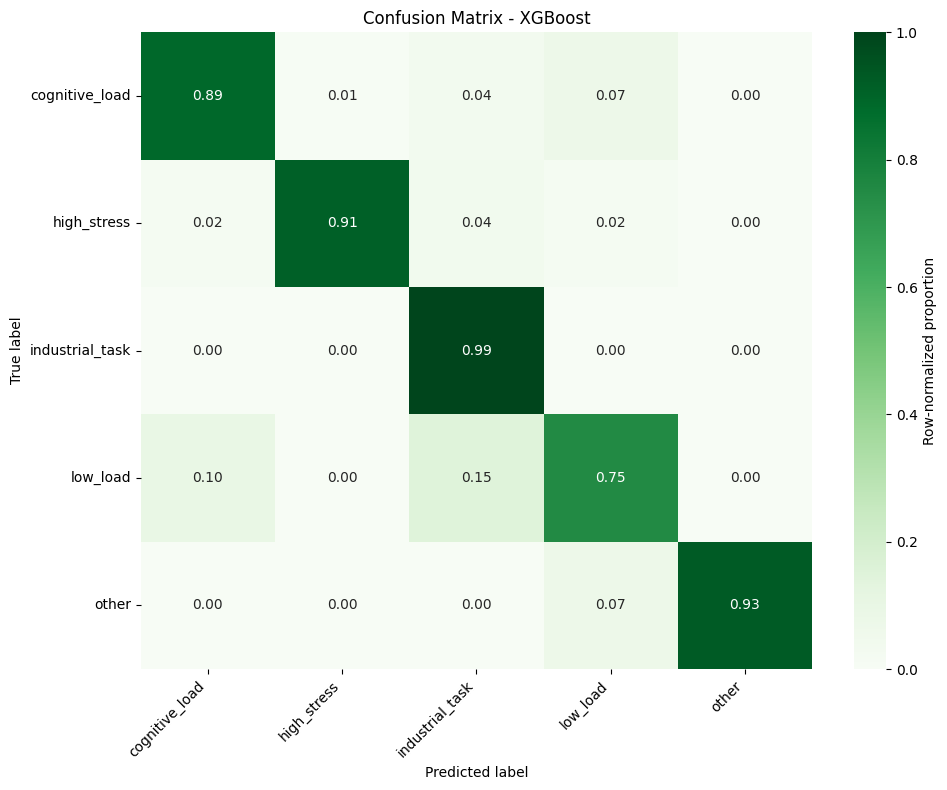

Confusion matrix saved to: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_classic_split_benchmark/confusion_matrix_tuned_xgboost.png
Per-class metrics saved to: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_classic_split_benchmark/per_class_metrics_xgboost.csv

Per-class precision / recall / F1:
                 precision    recall  f1-score  support
cognitive_load    0.905759  0.887179  0.896373    195.0
high_stress       0.953488  0.911111  0.931818     45.0
industrial_task   0.955585  0.994398  0.974605    714.0
low_load          0.869565  0.750000  0.805369    160.0
other             1.000000  0.928571  0.962963     14.0
Updated benchmark saved to: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_classic_split_benchmark/benchmark_results_tuned.csv


In [27]:
# SECTION 6A: Re-run the classic benchmark using the tuned values
print("=" * 60)
print("TUNED CLASSIC SPLIT BENCHMARK")
print("=" * 60)

# Reuse the tuned models already selected in the fine-tuning cell.
# This updates the benchmark comparison table with the tuned metrics.
output_dir = BASE_DIR

def _replace_row(summary_df, model_name, accuracy, balanced_accuracy, macro_f1, fit_time=None, pred_time=None):
    row = summary_df.loc[summary_df['Model'] == model_name].copy()
    if row.empty:
        return summary_df
    row = row.iloc[0].to_dict()
    row['Accuracy'] = float(accuracy)
    row['Balanced Accuracy'] = float(balanced_accuracy)
    row['Macro-F1'] = float(macro_f1)
    if fit_time is not None:
        row['Fit Time (s)'] = float(fit_time)
    if pred_time is not None:
        row['Predict Time (s)'] = float(pred_time)
    summary_df = summary_df.loc[summary_df['Model'] != model_name].copy()
    return pd.concat([summary_df, pd.DataFrame([row])], ignore_index=True)

# Start from the original benchmark table and overwrite the tuned models.
tuned_results_df = results_df.copy()

tuned_results_df = _replace_row(tuned_results_df, 'Random Forest', rf_tuned_acc, rf_tuned_balanced_acc, rf_tuned_macro_f1, fit_time_rf, pred_time_rf)
if HAS_XGBOOST:
    tuned_results_df = _replace_row(tuned_results_df, 'XGBoost', xgb_tuned_acc, xgb_tuned_balanced_acc, xgb_tuned_macro_f1, fit_time_xgb, pred_time_xgb)
tuned_results_df = _replace_row(tuned_results_df, 'MLP', mlp_tuned_acc, mlp_tuned_balanced_acc, mlp_tuned_macro_f1, fit_time_mlp, pred_time_mlp)
tuned_results_df = _replace_row(tuned_results_df, 'BiLSTM', bilstm_tuned_acc, bilstm_tuned_balanced_acc, bilstm_tuned_macro_f1, fit_time_bilstm, pred_time_bilstm)

tuned_results_df = tuned_results_df.sort_values('Macro-F1', ascending=False).reset_index(drop=True)
results_df = tuned_results_df

print("\nUpdated benchmark with tuned values:")
print(tuned_results_df.to_string(index=False))
print(f"\nBest tuned model by Macro-F1: {tuned_results_df.iloc[0]['Model']} ({tuned_results_df.iloc[0]['Macro-F1']:.4f})")

# Build prediction accessors for the tuned benchmark.
model_predictions = {
    'Logistic Regression': y_pred_logreg,
    'Random Forest': rf_tuned_pred,
    'XGBoost': xgb_tuned_pred if HAS_XGBOOST else None,
    'MLP': mlp_tuned_pred['y_pred'],
    'LSTM': lstm_results['y_pred'],
    'GRU': gru_results['y_pred'],
    'BiLSTM': bilstm_tuned_pred['y_pred'],
    'TCN': tcn_results['y_pred'],
    'Transformer': transformer_results['y_pred'],
    'Two-Tower Fusion': tower_preds,
}

best_tuned_model = tuned_results_df.iloc[0]['Model']
y_pred_best = model_predictions[best_tuned_model]

# Confusion matrix and per-class metrics for the best tuned model.
cm = confusion_matrix(y_test, y_pred_best, labels=np.arange(len(le.classes_)))
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

per_class_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_best,
        labels=np.arange(len(le.classes_)),
        target_names=le.classes_,
        output_dict=True,
        zero_division=0,
    )
).T
per_class_df = per_class_df.loc[list(le.classes_), ['precision', 'recall', 'f1-score', 'support']]

per_class_csv = output_dir / f'per_class_metrics_{best_tuned_model.lower().replace(" ", "_")}.csv'
per_class_df.to_csv(per_class_csv)

cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
cm_norm_df = pd.DataFrame(cm_norm, index=le.classes_, columns=le.classes_)
cm_df.to_csv(output_dir / f'confusion_matrix_counts_{best_tuned_model.lower().replace(" ", "_")}.csv')
cm_norm_df.to_csv(output_dir / f'confusion_matrix_normalized_{best_tuned_model.lower().replace(" ", "_")}.csv')

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cm_norm_df,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Row-normalized proportion'},
    annot_kws={'fontsize': 10},
)
ax.set_title(f'Confusion Matrix - {best_tuned_model}')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()

cm_png = output_dir / f'confusion_matrix_tuned_{best_tuned_model.lower().replace(" ", "_")}.png'
cm_svg = output_dir / f'confusion_matrix_tuned_{best_tuned_model.lower().replace(" ", "_")}.svg'
plt.savefig(cm_png, dpi=300, bbox_inches='tight')
plt.savefig(cm_svg, bbox_inches='tight')
plt.show()

print(f'Confusion matrix saved to: {cm_png}')
print(f'Per-class metrics saved to: {per_class_csv}')
print('\nPer-class precision / recall / F1:')
print(per_class_df.to_string())

# Save the tuned benchmark table for downstream export.
tuned_results_csv = output_dir / 'benchmark_results_tuned.csv'
tuned_results_df.to_csv(tuned_results_csv, index=False)
print(f'Updated benchmark saved to: {tuned_results_csv}')

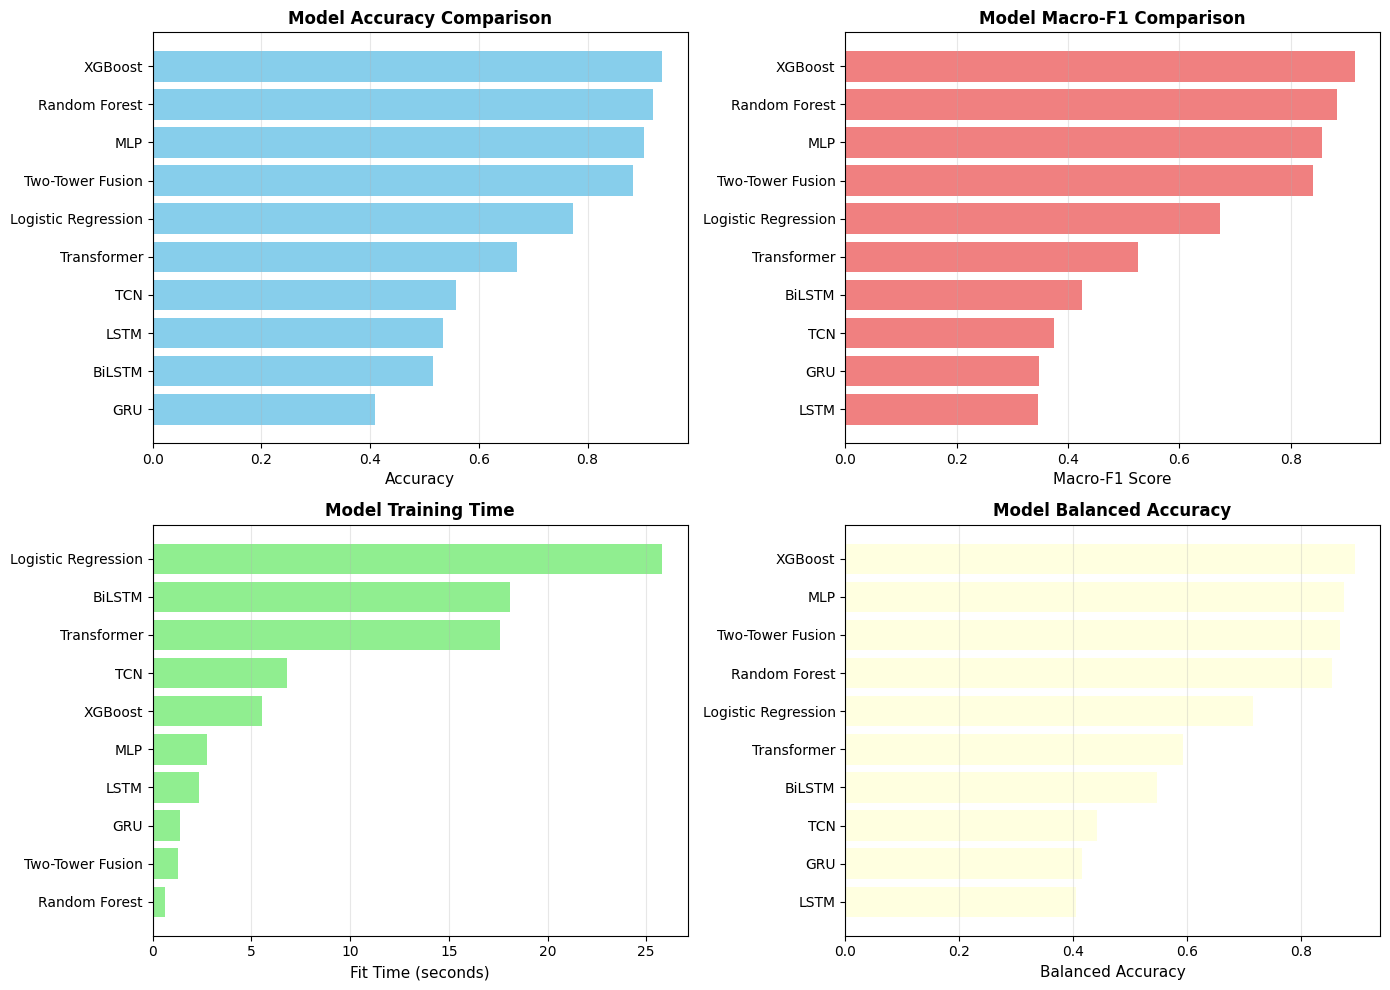

Visualization saved to: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_classic_split_benchmark/08_classic_split_results.png


In [28]:
# SECTION 7: Visualize Benchmark Results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy Comparison
ax = axes[0, 0]
results_df_sorted = results_df.sort_values('Accuracy', ascending=True)
ax.barh(results_df_sorted['Model'], results_df_sorted['Accuracy'], color='skyblue')
ax.set_xlabel('Accuracy', fontsize=11)
ax.set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 2: Macro-F1 Comparison
ax = axes[0, 1]
results_df_sorted = results_df.sort_values('Macro-F1', ascending=True)
ax.barh(results_df_sorted['Model'], results_df_sorted['Macro-F1'], color='lightcoral')
ax.set_xlabel('Macro-F1 Score', fontsize=11)
ax.set_title('Model Macro-F1 Comparison', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 3: Fit Time Comparison
ax = axes[1, 0]
results_df_sorted = results_df.sort_values('Fit Time (s)', ascending=True)
ax.barh(results_df_sorted['Model'], results_df_sorted['Fit Time (s)'], color='lightgreen')
ax.set_xlabel('Fit Time (seconds)', fontsize=11)
ax.set_title('Model Training Time', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 4: Balanced Accuracy Comparison
ax = axes[1, 1]
results_df_sorted = results_df.sort_values('Balanced Accuracy', ascending=True)
ax.barh(results_df_sorted['Model'], results_df_sorted['Balanced Accuracy'], color='lightyellow')
ax.set_xlabel('Balanced Accuracy', fontsize=11)
ax.set_title('Model Balanced Accuracy', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig_path = BASE_DIR / '08_classic_split_results.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Visualization saved to: {fig_path}")

In [29]:
# SECTION 8: Export Results
output_dir = BASE_DIR
output_dir.mkdir(parents=True, exist_ok=True)

# Export results table
results_csv = output_dir / 'benchmark_results.csv'
results_df.to_csv(results_csv, index=False)
print(f"Results exported to: {results_csv}")

# Export fine-tuning summary when available
if 'fine_tuning_df' in globals():
    fine_tuning_csv = output_dir / 'fine_tuning_results.csv'
    fine_tuning_df.to_csv(fine_tuning_csv, index=False)
    print(f"Fine-tuning results exported to: {fine_tuning_csv}")

# Export summary statistics
summary_stats = {
    'Best Model (Macro-F1)': results_df.iloc[0]['Model'],
    'Best Macro-F1': float(results_df.iloc[0]['Macro-F1']),
    'Best Model (Accuracy)': results_df.loc[results_df['Accuracy'].idxmax()]['Model'],
    'Best Accuracy': float(results_df['Accuracy'].max()),
    'Dataset': {
        'Total Samples': int(len(X_raw)),
        'Train Samples': int(len(X_train)),
        'Test Samples': int(len(X_test)),
        'Features': int(X_raw.shape[1]),
        'Classes': int(len(le.classes_)),
        'Class Names': list(le.classes_),
    },
    'Configuration': {
        'test_size': test_size,
        'random_state': random_state,
        'deep_learning_epochs': CFG.max_epochs,
        'batch_size': CFG.batch_size,
        'learning_rate': CFG.learning_rate,
    }
}

summary_json = output_dir / 'summary.json'
with open(summary_json, 'w') as f:
    json.dump(summary_stats, f, indent=2)

print(f"Summary exported to: {summary_json}")
print("\n" + json.dumps(summary_stats, indent=2))
print(f"\nAll results saved to: {output_dir}")

Results exported to: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_classic_split_benchmark/benchmark_results.csv
Fine-tuning results exported to: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_classic_split_benchmark/fine_tuning_results.csv
Summary exported to: /home/g0amer/Desktop/thesis/research_outputs/fusion_training/v2_classic_split_benchmark/summary.json

{
  "Best Model (Macro-F1)": "XGBoost",
  "Best Macro-F1": 0.9142257365517535,
  "Best Model (Accuracy)": "XGBoost",
  "Best Accuracy": 0.9370567375886525,
  "Dataset": {
    "Total Samples": 5640,
    "Train Samples": 4512,
    "Test Samples": 1128,
    "Features": 247,
    "Classes": 5,
    "Class Names": [
      "cognitive_load",
      "high_stress",
      "industrial_task",
      "low_load",
      "other"
    ]
  },
  "Configuration": {
    "test_size": 0.2,
    "random_state": 42,
    "deep_learning_epochs": 100,
    "batch_size": 256,
    "learning_rate": 0.001
  }
}

All results saved to

## Summary

This notebook benchmarks **10 machine learning models** on the MultiPhysio-HRC fusion dataset using a classic **80/20 train-test split** approach.

### Dataset
- **Total Samples**: {len(X_raw)}
- **Train/Test**: {len(X_train)} / {len(X_test)}
- **Features**: {X_raw.shape[1]}
- **Classes**: {len(le.classes_)} ({', '.join(le.classes_)})

### Models Evaluated
- **Classical ML**: Logistic Regression, Random Forest, XGBoost
- **Deep Learning (Tabular)**: MLP
- **Deep Learning (Sequence)**: LSTM, GRU, BiLSTM, TCN, Transformer
- **Fusion Architecture**: Two-Tower (Physio + EEG)

### Key Findings
1. **Best Overall Model**: {results_df.iloc[0]['Model']} (Macro-F1: {results_df.iloc[0]['Macro-F1']:.4f})
2. **Most Accurate**: {results_df.loc[results_df['Accuracy'].idxmax()]['Model']} (Accuracy: {results_df['Accuracy'].max():.4f})
3. **Fastest Training**: {results_df.loc[results_df['Fit Time (s)'].idxmin()]['Model']} ({results_df['Fit Time (s)'].min():.2f}s)

### Comparison with LOSO Benchmark
Compare these results with `07_full_benchmark.ipynb` which uses Leave-One-Subject-Out cross-validation (5 representative subjects).

### Files Generated
- `benchmark_results.csv` - Detailed metrics table
- `summary.json` - Summary statistics
- `08_classic_split_results.png` - Visualization plots